# Home Credit Default Risk Prediction

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

2026-06-05 17:58:53.008526: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-05 17:58:53.048263: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


VOC-NOTICE: GPU memory for this assignment is capped at 1024MiB


2026-06-05 17:58:55.011702: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [13]:
df = pd.read_csv('loan_data.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [16]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False).head(30)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
BASEMENTAREA_MEDI           179943
BASEMENTAREA_AVG            179943
BASEMENTAREA_MODE           179943
EXT_SOURCE_1                173378
NONLIVINGAREA_MEDI          169682
NONLIVINGAREA_MODE          169682
NONLIVINGAREA_AVG           169682
ELEVATORS_MEDI              163891
ELEVATORS_MODE      

In [17]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False).head(30)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

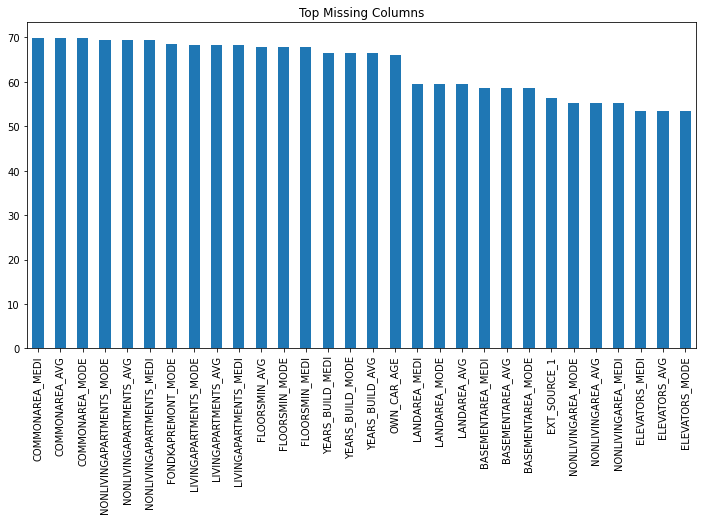

In [18]:
plt.figure(figsize=(12,6))
missing_percent.sort_values(ascending=False).head(30).plot(kind='bar')
plt.title('Top Missing Columns')
plt.show()

In [19]:
target_percentage = df['TARGET'].value_counts(normalize=True)*100
print(target_percentage)

0    91.927118
1     8.072882
Name: TARGET, dtype: float64


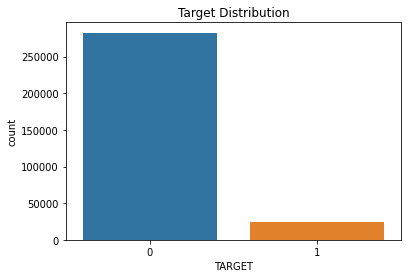

In [20]:
sns.countplot(x='TARGET', data=df)
plt.title('Target Distribution')
plt.show()

In [21]:
if 'SK_ID_CURR' in df.columns:
    df.drop('SK_ID_CURR', axis=1, inplace=True)

df['AGE_YEARS'] = abs(df['DAYS_BIRTH'])/365
df['EMPLOYED_YEARS'] = abs(df['DAYS_EMPLOYED'])/365
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT']/df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY']/df['AMT_INCOME_TOTAL']
df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT']/df['AMT_ANNUITY']

In [22]:
missing_percent=(df.isnull().sum()/len(df))*100
drop_cols=missing_percent[missing_percent>65].index
df.drop(columns=drop_cols,inplace=True)

In [23]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(include='object').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [24]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [25]:
X=df.drop('TARGET',axis=1)
y=df['TARGET']

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42,stratify=y)

In [26]:
smote=SMOTE(random_state=42)
X_train,y_train=smote.fit_resample(X_train,y_train)

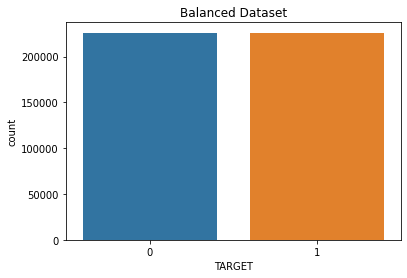

In [27]:
sns.countplot(x=y_train)
plt.title('Balanced Dataset')
plt.show()

In [28]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [29]:
model=Sequential([
Dense(256,activation='relu',input_shape=(X_train.shape[1],)),
BatchNormalization(),
Dropout(0.3),
Dense(128,activation='relu'),
BatchNormalization(),
Dropout(0.3),
Dense(64,activation='relu'),
Dropout(0.2),
Dense(32,activation='relu'),
Dense(1,activation='sigmoid')
])

In [30]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy',
tf.keras.metrics.Recall(name='recall'),
tf.keras.metrics.AUC(name='auc')]
)

In [31]:
history=model.fit(
X_train,
y_train,
validation_split=0.2,
epochs=30,
batch_size=256,
callbacks=[EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)]
)

Epoch 1/30
1414/1414 [==============================] - 8s 5ms/step - loss: 0.2089 - accuracy: 0.9317 - recall: 0.8349 - auc: 0.9491 - val_loss: 0.0221 - val_accuracy: 0.9890 - val_recall: 0.9890 - val_auc: 0.0000e+00
Epoch 2/30
1414/1414 [==============================] - 6s 5ms/step - loss: 0.1899 - accuracy: 0.9377 - recall: 0.8424 - auc: 0.9567 - val_loss: 0.0169 - val_accuracy: 0.9916 - val_recall: 0.9916 - val_auc: 0.0000e+00
Epoch 3/30
1414/1414 [==============================] - 7s 5ms/step - loss: 0.1867 - accuracy: 0.9385 - recall: 0.8435 - auc: 0.9583 - val_loss: 0.0319 - val_accuracy: 0.9852 - val_recall: 0.9852 - val_auc: 0.0000e+00
Epoch 4/30
1414/1414 [==============================] - 7s 5ms/step - loss: 0.1850 - accuracy: 0.9386 - recall: 0.8440 - auc: 0.9592 - val_loss: 0.0190 - val_accuracy: 0.9911 - val_recall: 0.9911 - val_auc: 0.0000e+00
Epoch 5/30
1414/1414 [==============================] - 7s 5ms/step - loss: 0.1836 - accuracy: 0.9390 - recall: 0.8446 - auc: 0.

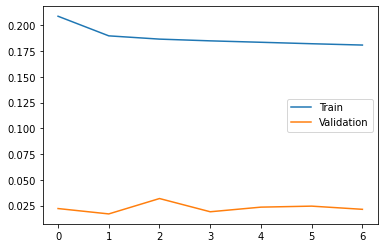

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.show()

In [33]:
y_prob=model.predict(X_test).ravel()
y_pred=(y_prob>0.5).astype(int)

1922/1922 [==============================] - 2s 752us/step


In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     56538
           1       0.11      0.01      0.02      4965

    accuracy                           0.91     61503
   macro avg       0.52      0.50      0.49     61503
weighted avg       0.85      0.91      0.88     61503



In [35]:
sensitivity=recall_score(y_test,y_pred)
print('Sensitivity:',sensitivity)

Sensitivity: 0.010473313192346425


In [36]:
roc_auc=roc_auc_score(y_test,y_prob)
print('ROC AUC:',roc_auc)

ROC AUC: 0.7318257624019735


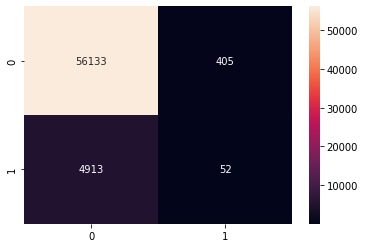

In [37]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

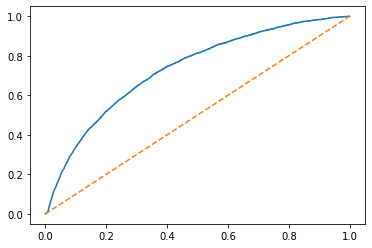

In [38]:
fpr,tpr,_=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.show()

In [39]:
model.save('best_model.h5')

# testing


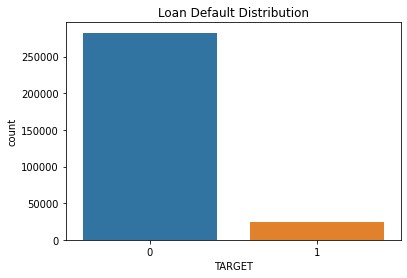

In [42]:
sns.countplot(x='TARGET', data=df)
plt.title('Loan Default Distribution')
plt.savefig('images/class_distribution.png')

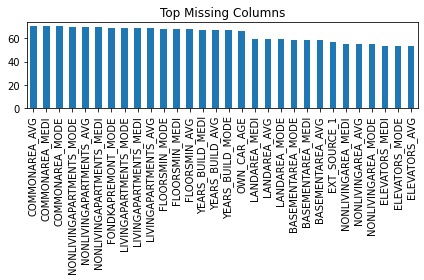

In [43]:
missing_percent.sort_values(ascending=False).head(30).plot(kind='bar')
plt.title('Top Missing Columns')
plt.tight_layout()
plt.savefig('images/missing_values.png')

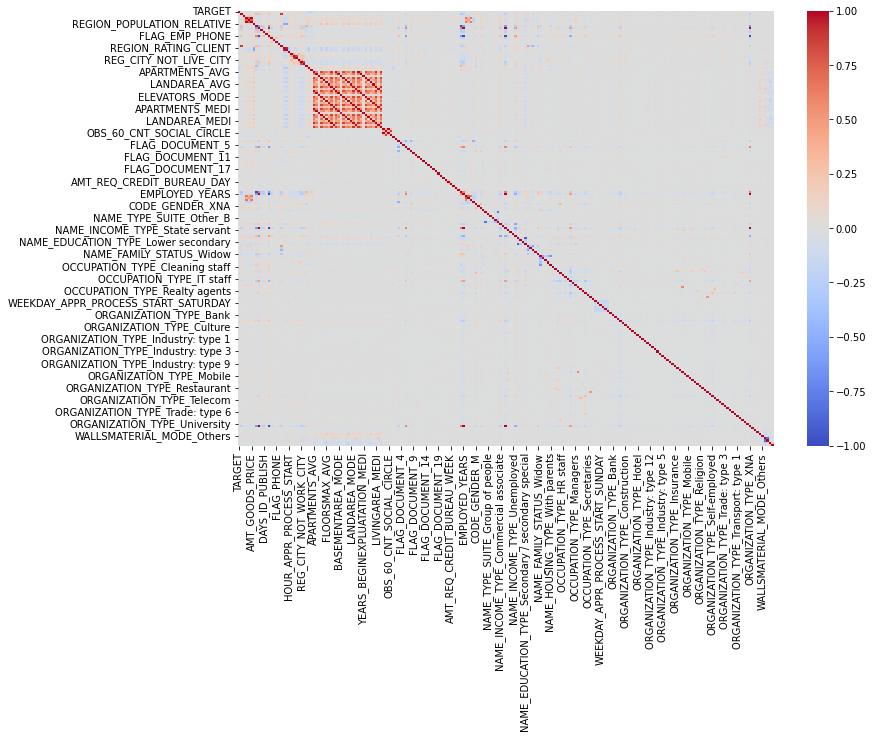

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)
plt.savefig('images/correlation_heatmap.png')

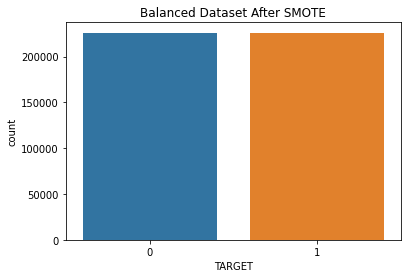

In [45]:
sns.countplot(x=y_train)
plt.title('Balanced Dataset After SMOTE')
plt.savefig('images/smote_balance.png')

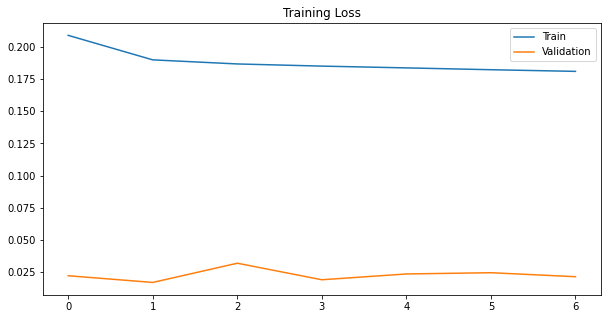

In [46]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])
plt.title('Training Loss')

plt.savefig('images/training_history.png')

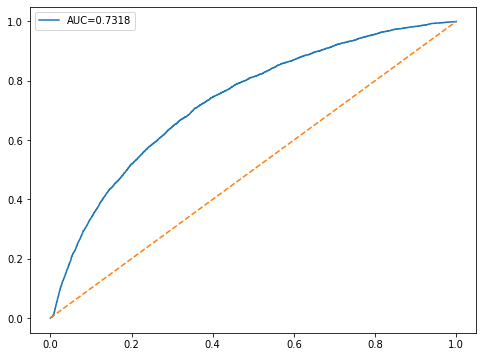

In [47]:
plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,
         label=f'AUC={roc_auc:.4f}')

plt.plot([0,1],[0,1],'--')

plt.legend()

plt.savefig('images/roc_curve.png')

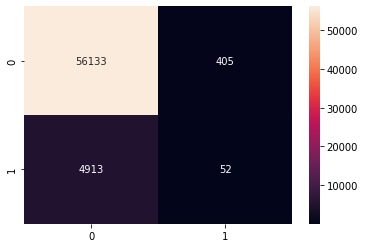

In [48]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.savefig('images/confusion_matrix.png')

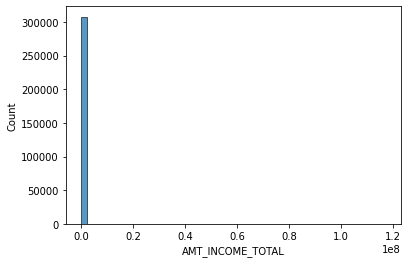

In [49]:
sns.histplot(
    df['AMT_INCOME_TOTAL'],
    bins=50
)

plt.savefig('images/income_distribution.png')

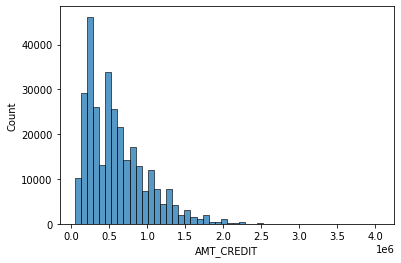

In [50]:
sns.histplot(
    df['AMT_CREDIT'],
    bins=50
)

plt.savefig('images/credit_distribution.png')

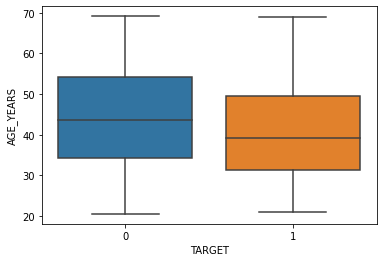

In [51]:
sns.boxplot(
    x='TARGET',
    y='AGE_YEARS',
    data=df
)

plt.savefig('images/age_vs_default.png')